In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import ListedColormap

def visualize_segmentation_classes(image_path, mask_path, output_dir=None):

    class_names = [
        "Unlabeled", "Building", "Fence", "Other", "Pedestrian", 
        "Pole", "Roadline", "Road", "Sidewalk", "Vegetation", 
        "Car", "Wall", "Traffic sign"
    ]
    
    # Define a colormap for visualization
    colors = [
        [0, 0, 0],        # Unlabeled - black
        [70, 70, 70],     # Building - dark gray
        [190, 153, 153],  # Fence - light brown
        [250, 170, 160],  # Other - salmon
        [220, 20, 60],    # Pedestrian - crimson
        [153, 153, 153],  # Pole - gray
        [157, 234, 50],   # Roadline - bright green
        [128, 64, 128],   # Road - purple
        [244, 35, 232],   # Sidewalk - pink
        [107, 142, 35],   # Vegetation - olive green
        [0, 0, 142],      # Car - dark blue
        [102, 102, 156],  # Wall - slate blue
        [220, 220, 0]     # Traffic sign - yellow
    ]
    
    # Normalize colors to [0, 1] for matplotlib
    colors = np.array(colors) / 255.0
    cmap = ListedColormap(colors)
    
    # Load image and mask
    image = Image.open(image_path).convert('RGB')
    mask = Image.open(mask_path)
    
    # Convert mask to numpy array and get the first channel (class IDs)
    mask_array = np.array(mask)
    if len(mask_array.shape) == 3:
        class_mask = mask_array[:, :, 0]  # Extract the first channel for class IDs
    else:
        class_mask = mask_array
    
    # Verify the number of unique labels in the segmentation mask
    unique_classes = np.unique(class_mask)
    print(f"Unique class IDs in the mask: {unique_classes}")
    if len(unique_classes) != 13:
        print(f"Warning: Expected 13 unique classes, but found {len(unique_classes)}.")
    
    # Set up the figure layout
    num_classes = len(unique_classes)
    fig_rows = int(np.ceil((num_classes + 2) / 3))  # +2 for image and full mask
    
    fig, axes = plt.subplots(fig_rows, 3, figsize=(15, 5 * fig_rows))
    if fig_rows == 1:
        axes = axes.reshape(1, -1)
    
    # Plot original image
    axes[0, 0].imshow(image)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Plot full segmentation mask with color mapping
    colored_mask = cmap(class_mask)
    axes[0, 1].imshow(colored_mask)
    axes[0, 1].set_title('Full Segmentation Mask')
    axes[0, 1].axis('off')
    
    # Create a legend for the classes
    legend_elements = [plt.Rectangle((0, 0), 1, 1, color=colors[i], label=class_names[i]) 
                      for i in range(len(class_names)) if i in unique_classes]
    axes[0, 2].legend(handles=legend_elements, loc='center')
    axes[0, 2].axis('off')
    axes[0, 2].set_title('Class Legend')
    
    # Plot individual class masks
    idx = 0
    for row in range(1, fig_rows):
        for col in range(3):
            if idx < num_classes:
                class_id = unique_classes[idx]
                idx += 1
                
                # Create binary mask for this class
                binary_mask = (class_mask == class_id).astype(np.uint8)
                
                # Plot the binary mask
                axes[row, col].imshow(binary_mask)
                axes[row, col].set_title(f'Class {class_id}: {class_names[class_id]}')
                axes[row, col].axis('off')
            else:
                axes[row, col].axis('off')
    
    plt.tight_layout()
    
    # Save figure if output directory is provided
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        base_name = os.path.basename(image_path).split('.')[0]
        plt.savefig(os.path.join(output_dir, f"{base_name}_visualization.png"))
    
    plt.show()

# Example usage
if __name__ == "__main__":
    # Path to a sample image and mask
    image_path = "Dataset/2/dataset_256/train/images/02_00_012.png"
    mask_path = "Dataset/2/dataset_256/train/labels/02_00_012.png"
    # visualize_segmentation_classes(image_path, mask_path)



Using device: cuda
Training images: 2000
Test images: 500
Training samples: 1600
Validation samples: 400
Test samples: 500
UNet(
  (inc): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(1

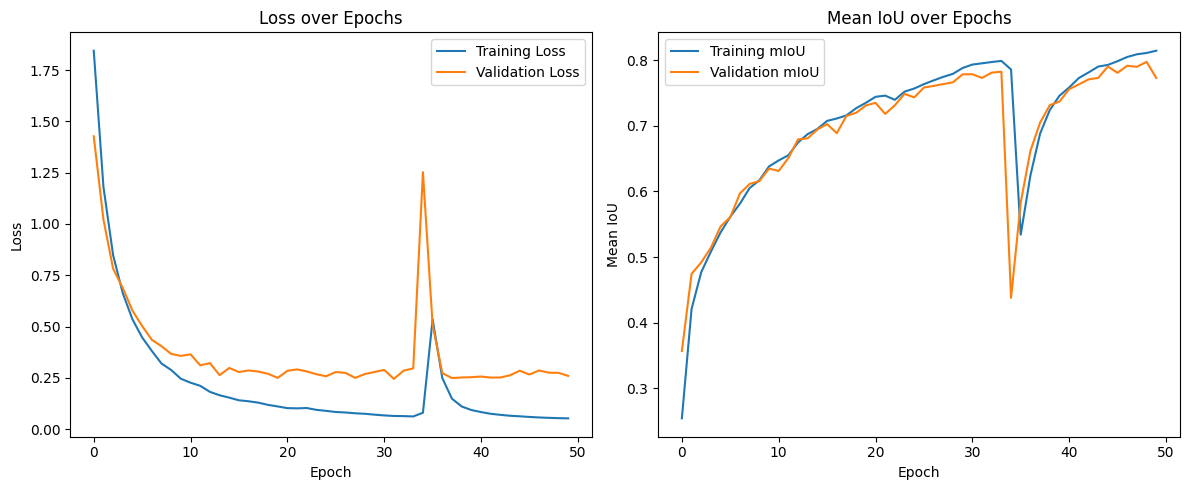

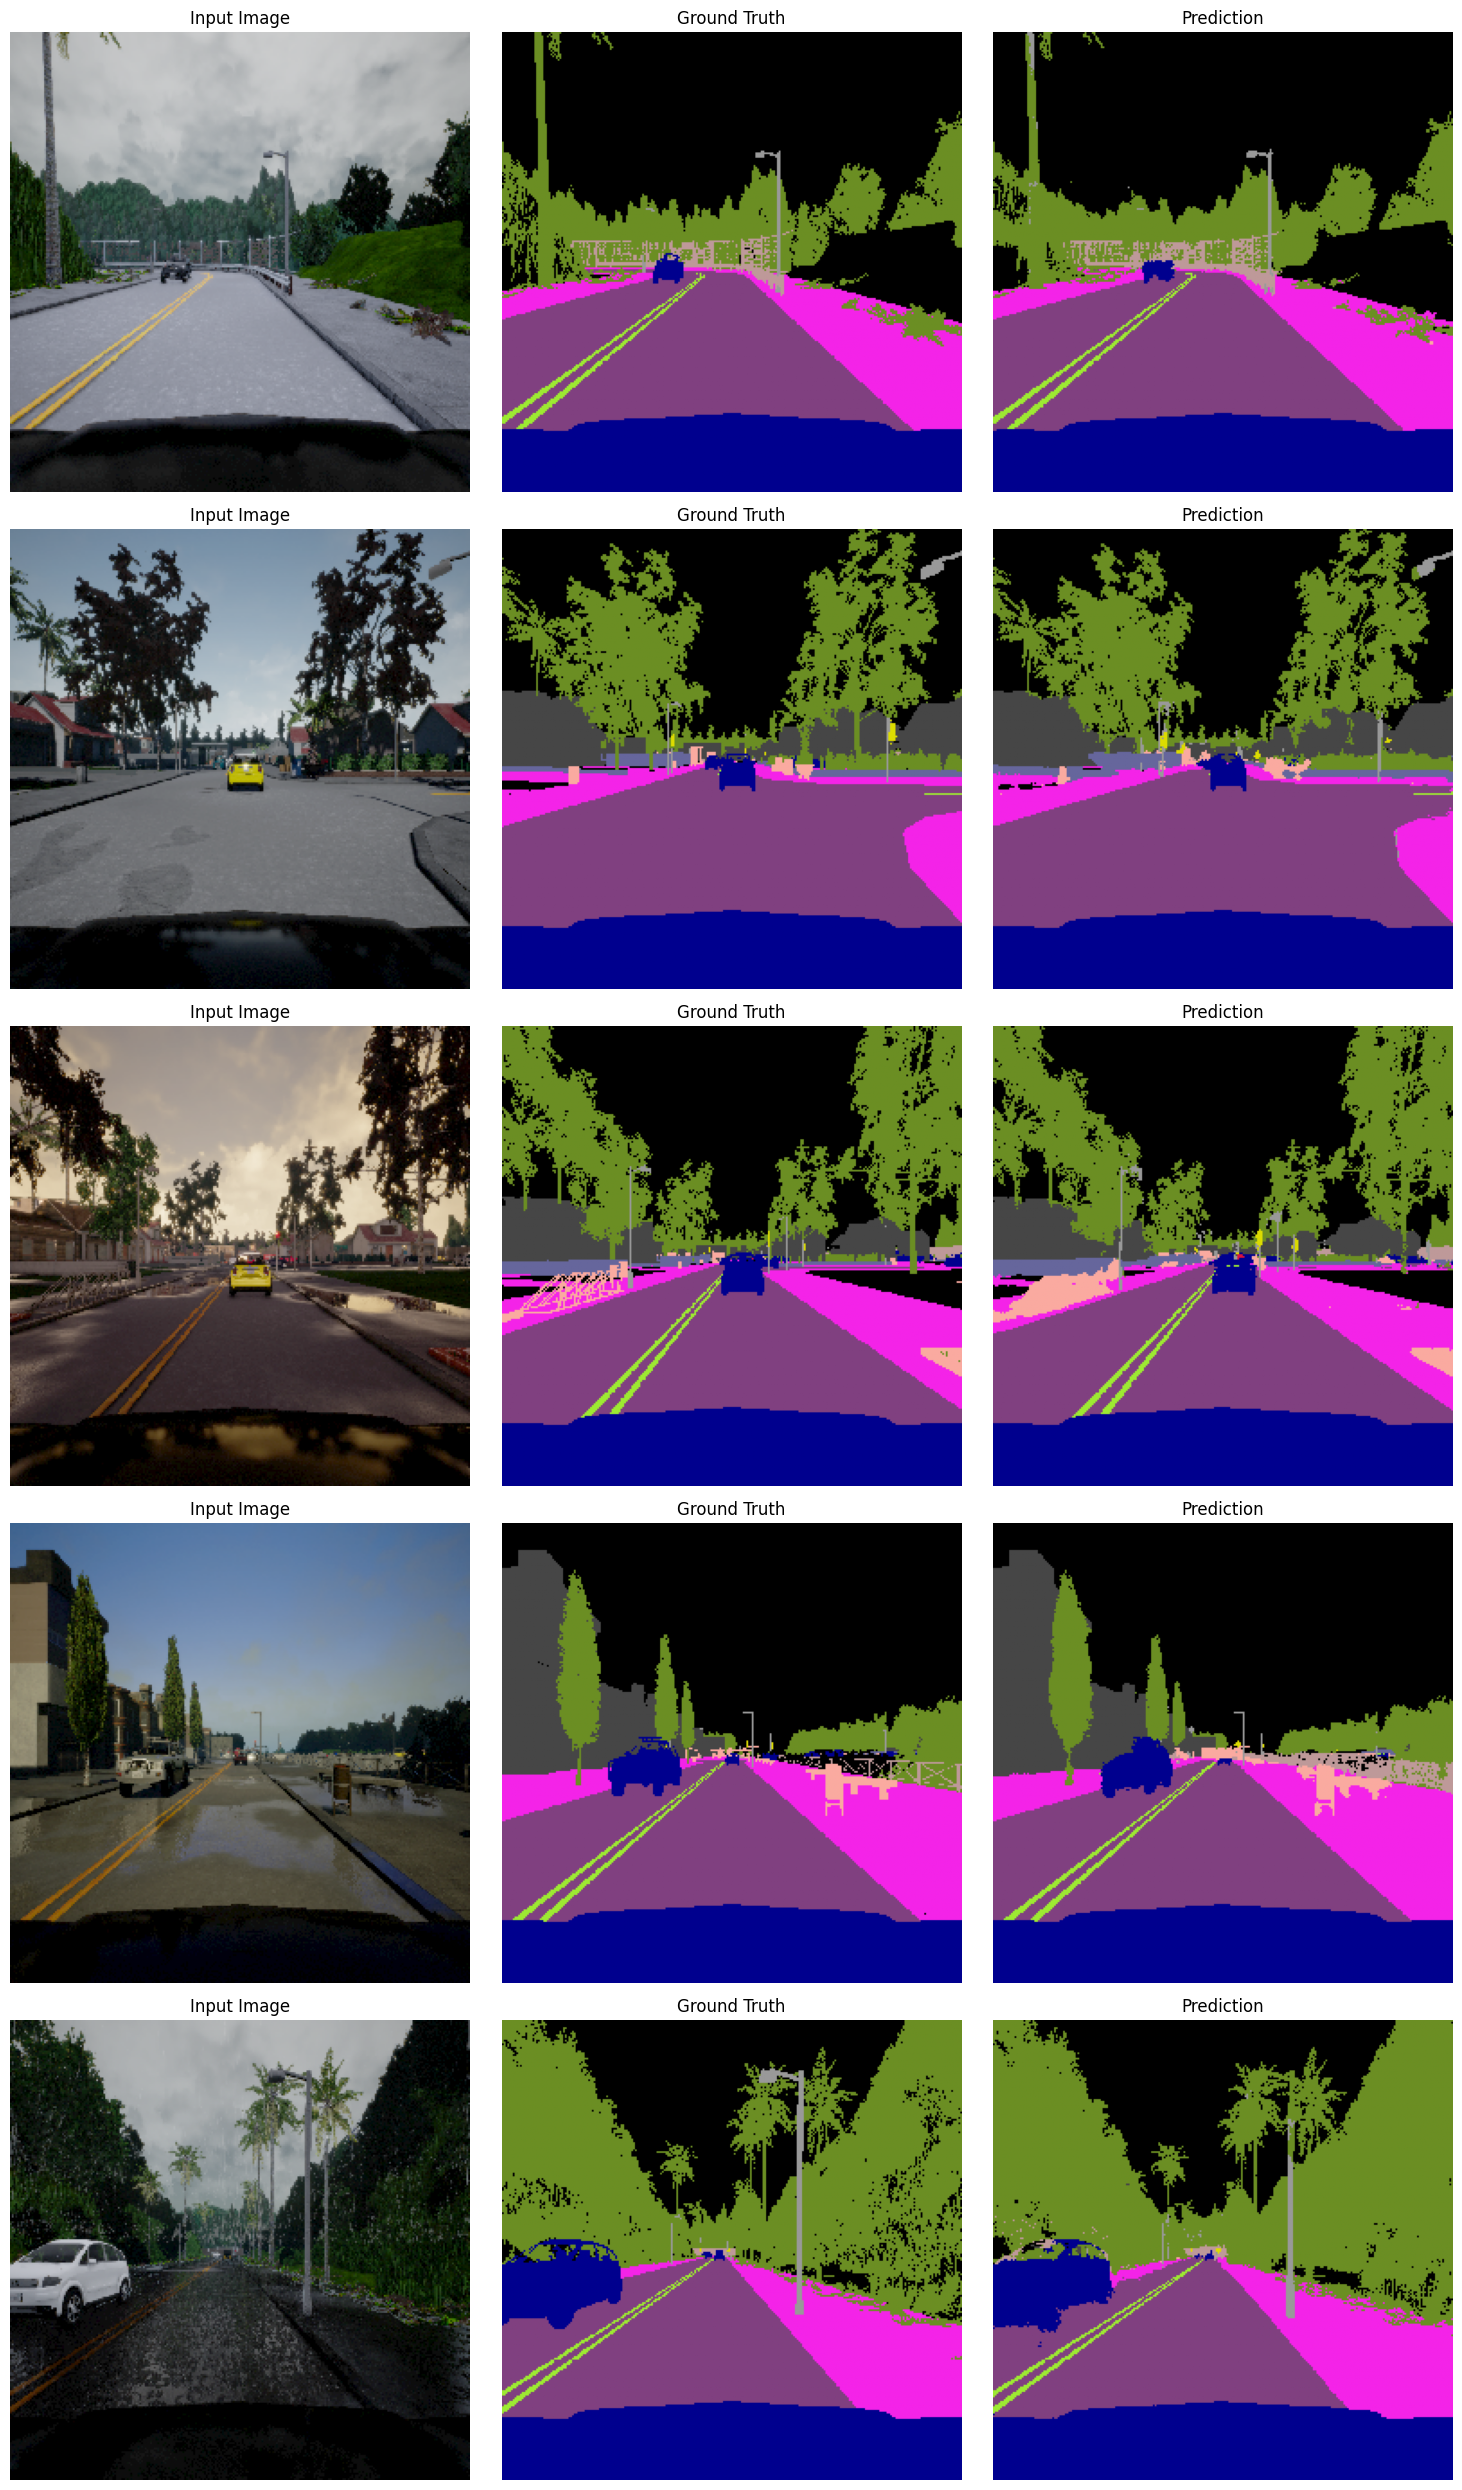

In [5]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.colors import ListedColormap

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define constants
IMG_WIDTH = 256
IMG_HEIGHT = 256
NUM_CLASSES = 13
BATCH_SIZE = 16
EPOCHS = 50
VAL_SPLIT = 0.2
LEARNING_RATE = 1e-4
DATASET_PATH = "Dataset/2/dataset_256"

# Define class names and colors for visualization
CLASS_NAMES = [
    "Unlabeled", "Building", "Fence", "Other", "Pedestrian", 
    "Pole", "Roadline", "Road", "Sidewalk", "Vegetation", 
    "Car", "Wall", "Traffic sign"
]

COLORS = np.array([
    [0, 0, 0],        # Unlabeled - black
    [70, 70, 70],     # Building - dark gray
    [190, 153, 153],  # Fence - light brown
    [250, 170, 160],  # Other - salmon
    [220, 20, 60],    # Pedestrian - crimson
    [153, 153, 153],  # Pole - gray
    [157, 234, 50],   # Roadline - bright green
    [128, 64, 128],   # Road - purple
    [244, 35, 232],   # Sidewalk - pink
    [107, 142, 35],   # Vegetation - olive green
    [0, 0, 142],      # Car - dark blue
    [102, 102, 156],  # Wall - slate blue
    [220, 220, 0]     # Traffic sign - yellow
]) / 255.0  # Normalize to [0, 1]

# Create a color map for visualization
COLORMAP = ListedColormap(COLORS)

###################
# DATASET CLASSES #
###################

class SegmentationDataset(Dataset):
    """Dataset class for semantic segmentation"""
    
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform
        
    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.img_paths[idx]
        img = Image.open(img_path).convert('RGB')
        img = np.array(img) / 255.0  # Normalize to [0, 1]
        img = img.transpose(2, 0, 1)  # Convert to CxHxW format
        img = torch.from_numpy(img).float()
        
        # Load mask
        mask_path = self.mask_paths[idx]
        mask = Image.open(mask_path)
        mask = np.array(mask)
        if len(mask.shape) > 2:
            mask = mask[:, :, 0]  # Take only the first channel if multi-channel
        mask = torch.from_numpy(mask).long()
        
        # Apply transformations if specified
        if self.transform:
            img, mask = self.transform(img, mask)
            
        return img, mask

def load_data_paths(dataset_path):
    """Load paths to images and masks"""
    # Get paths to training images and masks
    train_img_paths = sorted(glob.glob(os.path.join(dataset_path, "train", "images", "*.png")))
    train_mask_paths = sorted(glob.glob(os.path.join(dataset_path, "train", "labels", "*.png")))
    
    # Get paths to test images and masks
    test_img_paths = sorted(glob.glob(os.path.join(dataset_path, "test", "images", "*.png")))
    test_mask_paths = sorted(glob.glob(os.path.join(dataset_path, "test", "labels", "*.png")))
    
    print(f"Training images: {len(train_img_paths)}")
    print(f"Test images: {len(test_img_paths)}")
    
    return train_img_paths, train_mask_paths, test_img_paths, test_mask_paths

def prepare_dataloaders(train_img_paths, train_mask_paths, test_img_paths, test_mask_paths):
    """Prepare dataloaders for training, validation, and testing"""
    # Create datasets
    train_dataset = SegmentationDataset(train_img_paths, train_mask_paths)
    test_dataset = SegmentationDataset(test_img_paths, test_mask_paths)
    
    # Split training data into training and validation
    val_size = int(len(train_dataset) * VAL_SPLIT)
    train_size = len(train_dataset) - val_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                             num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=4, pin_memory=True)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    
    return train_loader, val_loader, test_loader, test_dataset

#######################
# U-NET ARCHITECTURE #
#######################

class DoubleConv(nn.Module):
    """Double Convolution block with padding"""
    
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    """Downsampling block with maxpool followed by double conv"""
    
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
        
    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upsampling block followed by concatenation and double conv"""
    
    def __init__(self, in_channels, out_channels):
        super(Up, self).__init__()
        
        # Use transpose conv (up-convolution) for upsampling
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
        
    def forward(self, x1, x2):
        x1 = self.up(x1)
        
        # Handle potential size differences for concatenation
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        
        if diffY > 0 or diffX > 0:
            x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, 
                            diffY // 2, diffY - diffY // 2])
        
        # Concatenate along the channel dimension
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    """U-Net architecture for semantic segmentation"""
    
    def __init__(self, n_channels=3, n_classes=NUM_CLASSES):
        super(UNet, self).__init__()
        
        # Initial double convolution
        self.inc = DoubleConv(n_channels, 64)
        
        # Contracting path (encoder)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)
        
        # Expansive path (decoder)
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        
        # Final 1x1 convolution to map to n_classes
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)
        
    def forward(self, x):
        # Encoder path with skip connections
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        # Decoder path using skip connections
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        # Final 1x1 convolution
        logits = self.outc(x)
        
        return logits

#######################
# TRAINING FUNCTIONS #
#######################

def calculate_class_weights(train_loader, device):
    """Calculate class weights based on the frequency of pixels"""
    class_counts = torch.zeros(NUM_CLASSES, device=device)
    
    print("Calculating class weights...")
    for _, masks in train_loader:
        masks = masks.to(device)
        for c in range(NUM_CLASSES):
            class_counts[c] += (masks == c).sum()
    
    # Calculate weights as inverse frequency
    total_pixels = class_counts.sum()
    class_weights = total_pixels / (class_counts * NUM_CLASSES + 1e-8)
    
    # Normalize weights
    class_weights = class_weights / class_weights.sum() * NUM_CLASSES
    
    print("Class weights:", class_weights.cpu().numpy())
    return class_weights

def calculate_iou(pred, target, num_classes=NUM_CLASSES):
    """Calculate IoU for each class and mean IoU"""
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)
    
    # Calculate IoU for each class
    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()
        
        if union == 0:
            ious.append(float('nan'))  # If there's no ground truth, don't include in the evaluation
        else:
            ious.append((intersection / union).item())
            
    # Calculate mean IoU only for classes that are present
    valid_ious = [iou for iou in ious if not np.isnan(iou)]
    if len(valid_ious) == 0:
        return 0  # Return 0 if there are no valid IoUs
    return np.mean(valid_ious)

def train_one_epoch(model, train_loader, optimizer, criterion, device):
    """Train the model for one epoch"""
    model.train()
    total_loss = 0
    total_iou = 0
    
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        outputs = model(images)
        
        # Calculate loss
        loss = criterion(outputs, masks)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Calculate IoU for current batch
        _, preds = torch.max(outputs, dim=1)
        batch_iou = calculate_iou(preds, masks)
        
        total_loss += loss.item()
        total_iou += batch_iou
        
    # Return average loss and IoU for the epoch
    return total_loss / len(train_loader), total_iou / len(train_loader)

def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0
    total_iou = 0
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Calculate loss
            loss = criterion(outputs, masks)
            total_loss += loss.item()
            
            # Calculate IoU for current batch
            _, preds = torch.max(outputs, dim=1)
            batch_iou = calculate_iou(preds, masks)
            total_iou += batch_iou
            
    # Return average loss and IoU for validation set
    return total_loss / len(val_loader), total_iou / len(val_loader)

def test(model, test_loader, device):
    """Test the model and return IoU"""
    model.eval()
    total_iou = 0
    
    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Calculate IoU for current batch
            _, preds = torch.max(outputs, dim=1)
            batch_iou = calculate_iou(preds, masks)
            total_iou += batch_iou
            
    # Return average IoU for test set
    return total_iou / len(test_loader)

#####################
# VISUALIZATION FUNCTIONS #
#####################

def visualize_predictions(model, test_dataset, test_img_paths, test_mask_paths, device, num_samples=5):
    """Visualize predictions on test samples"""
    model.eval()
    
    # Randomly select samples
    indices = np.random.choice(len(test_img_paths), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Get image and mask
            img, mask = test_dataset[idx]
            img = img.unsqueeze(0).to(device)  # Add batch dimension
            
            # Make prediction
            output = model(img)
            pred = torch.argmax(output, dim=1).squeeze().cpu().numpy()
            
            # Convert image back to numpy for display
            img = img.squeeze().cpu().numpy().transpose(1, 2, 0)  # CxHxW -> HxWxC
            mask = mask.cpu().numpy()
            
            # Plot
            axes[i, 0].imshow(img)
            axes[i, 0].set_title('Input Image')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(mask, cmap=COLORMAP, vmin=0, vmax=NUM_CLASSES-1)
            axes[i, 1].set_title('Ground Truth')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred, cmap=COLORMAP, vmin=0, vmax=NUM_CLASSES-1)
            axes[i, 2].set_title('Prediction')
            axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('unet_vanilla_predictions.png')
    plt.show()

def plot_training_history(train_losses, val_losses, train_ious, val_ious):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot losses
    ax1.plot(train_losses, label='Training Loss')
    ax1.plot(val_losses, label='Validation Loss')
    ax1.set_title('Loss over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    # Plot IoUs
    ax2.plot(train_ious, label='Training mIoU')
    ax2.plot(val_ious, label='Validation mIoU')
    ax2.set_title('Mean IoU over Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Mean IoU')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('unet_vanilla_training_history.png')
    plt.show()

#####################
# MAIN FUNCTION #
#####################

def main():
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load data paths
    train_img_paths, train_mask_paths, test_img_paths, test_mask_paths = load_data_paths(DATASET_PATH)
    
    # Prepare dataloaders
    train_loader, val_loader, test_loader, test_dataset = prepare_dataloaders(
        train_img_paths, train_mask_paths, test_img_paths, test_mask_paths
    )
    
    # Create model
    model = UNet(n_channels=3, n_classes=NUM_CLASSES).to(device)
    print(model)
    
    # Calculate class weights for balanced loss
    class_weights = calculate_class_weights(train_loader, device)
    
    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Train model
    train_losses = []
    val_losses = []
    train_ious = []
    val_ious = []
    best_val_iou = 0
    
    print(f"Starting training for {EPOCHS} epochs...")
    
    for epoch in range(EPOCHS):
        # Train one epoch
        train_loss, train_iou = train_one_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        train_ious.append(train_iou)
        
        # Validate
        val_loss, val_iou = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_ious.append(val_iou)
        
        # Print progress
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train mIoU: {train_iou:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val mIoU: {val_iou:.4f}")
        
        # Save best model
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), 'best_unet_vanilla.pth')
            print(f"Saved new best model with mIoU: {best_val_iou:.4f}")
    
    print(f"Training completed! Best validation mIoU: {best_val_iou:.4f}")
    
    # Load best model
    model.load_state_dict(torch.load('best_unet_vanilla.pth'))
    
    # Test the model
    test_iou = test(model, test_loader, device)
    print(f"Test mIoU: {test_iou:.4f}")
    
    # Plot training history
    plot_training_history(train_losses, val_losses, train_ious, val_ious)
    
    # Visualize predictions
    visualize_predictions(model, test_dataset, test_img_paths, test_mask_paths, device)

if __name__ == '__main__':
    main()